# Imports & Loads

In [1]:
# PATHS
TRAIN_PATH    = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\train.csv'
TEST_PATH     = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\test.csv'
SAMPLE_PATH   = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\sample_submission.csv'
ORIGINAL_PATH = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\student_health_dataset_50k.csv'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from lightgbm import LGBMClassifier

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from utils.evaluation import evaluate_oof
from utils.feature_engineering import engineer_features
from utils.probes import train_probe
from utils.final_probe import train_final_probe
from utils.predict_proba import predict_probe
import importlib
import utils.feature_engineering
from utils.feature_engineering import prepare_fold
from utils.error_analysis import analyze_errors

# importlib.reload(utils.feature_engineering)
import warnings
warnings.filterwarnings('ignore')

N_FOLDS   = 5
SEED      = 42
N_CLASSES = 3

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

TARGET       = 'health_condition'
CLASS_COLORS = {'fit': '#55A868', 'at-risk': '#4C72B0', 'unhealthy': '#C44E52'}

CAT_COLS = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']
NUM_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
            'step_count', 'exercise_duration', 'water_intake']

for df in [train, test, original]:
    for c in CAT_COLS:
        df[c] = df[c].astype(str).str.strip().str.lower().replace('nan', np.nan)

original[TARGET] = original[TARGET].astype(str).str.strip().str.lower()
original = original.drop(columns=['student_id', 'timestamp'])

print(f'Train    : {train.shape}')
print(f'Test     : {test.shape}')
print(f'Original : {original.shape}')

Train    : (690088, 15)
Test     : (295753, 14)
Original : (50000, 14)


In [3]:
id_train = train['id'].copy()
id_test = test['id'].copy()

train.drop(columns=['id'],inplace=True)
test.drop(columns=['id'],inplace=True)

In [4]:
STRESS_MISSING_TR = train['stress_level'].isna().values
STRESS_MISSING_TE = test['stress_level'].isna().values
SLEEP_MISSING_TR  = train['sleep_duration'].isna().values
SLEEP_MISSING_TE  = test['sleep_duration'].isna().values

print(f'train stress missing: {STRESS_MISSING_TR.sum():,} ({STRESS_MISSING_TR.mean()*100:.1f}%)')
print(f'test  stress missing: {STRESS_MISSING_TE.sum():,} ({STRESS_MISSING_TE.mean()*100:.1f}%)')
print(f'train sleep_duration missing : {SLEEP_MISSING_TR.sum():}({SLEEP_MISSING_TR.mean()*100:.1f}%')
print(f'test Sleep_duration missng   : {SLEEP_MISSING_TE.sum():}({SLEEP_MISSING_TE.mean()*100:.1f}%)')

train stress missing: 82,811 (12.0%)
test  stress missing: 35,490 (12.0%)
train sleep_duration missing : 75999(11.0%
test Sleep_duration missng   : 32571(11.0%)


# Feature Engineering

In [ ]:
train    = engineer_features(train)
test     = engineer_features(test)
original = engineer_features(original)

ENGINEERED_CATS = ['stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke','sleep_x_stress']
ENGINEERED_NUMS = ['sleep_lt6', 'sleep_ge7', 'steps_x_exercise',
                   'activity_efficiency', 'sleep_x_steps', 'bmi_band', 'sleep_dev']

FEATURES  = NUM_COLS + CAT_COLS + ENGINEERED_CATS + ENGINEERED_NUMS
MODEL_CATS = CAT_COLS + ENGINEERED_CATS
print(f'{len(FEATURES)} features ({len(MODEL_CATS)} categorical)')

24 features (10 categorical)


# Stress Level Recovery Probe

In [ ]:
stress_leak_features =['stress_level','stress_x_activity','stress_x_sleepq','stress_x_smoke','sleep_x_stress',TARGET]

stress_probe = train_probe(train=train,target='stress_level',features = FEATURES, categorical_cols=MODEL_CATS, missing_mask= STRESS_MISSING_TR,
                           leak_features=stress_leak_features, seed=SEED,n_splits=5)

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

Probe rows: 607,277
Features: 19

Accuracy          : 0.4151 (majority baseline 0.4311)
Balanced Accuracy : 0.4068

Classification Report:
              precision    recall  f1-score   support

        high     0.3955    0.3798    0.3875    177750
         low     0.3393    0.3778    0.3575    167708
      medium     0.4850    0.4629    0.4737    261819

    accuracy                         0.4151    607277
   macro avg     0.4066    0.4068    0.4062    607277
weighted avg     0.4186    0.4151    0.4164    607277



## Training a single model for stress probe

In [ ]:
final_stress_probe = train_final_probe(train=train, target = 'stress_level',features = FEATURES, categorical_cols=MODEL_CATS, missing_mask= STRESS_MISSING_TR,
                leak_features=stress_leak_features, seed=SEED)

probs_train_stress = predict_probe(train,final_stress_probe)

le = final_stress_probe['label_encoder']

for i, cls in enumerate(le.classes_):
    train[f"p_stress_{cls}"] = probs_train_stress[:, i]

probs_test_stress = predict_probe(test,final_stress_probe)
for i,cls in enumerate(le.classes_):
    test[f'p_stress_{cls}'] = probs_test_stress[:,i]

In [17]:
import joblib

joblib.dump(
    final_stress_probe,
    "../models/stress_probe_1.pkl"
)


['../models/stress_probe_1.pkl']

In [7]:
# Updating FEATURES and MODEL_CATS varable beacuse 3 new features just got added

FEATURES = [col for col in train.columns.tolist() if col !=TARGET]
MODEL_CATS = [col for col in train.select_dtypes(include='object').columns.tolist() if col != TARGET]

# Sleep Duration Recovery Probe

In [ ]:
y_region = np.digitize(
    train["sleep_duration"],
    bins=[6.0, 7.0]
)

train_copy = train.copy()
train_copy['y_region'] = y_region

sleep_leak = ['sleep_lt6','sleep_ge7','sleep_dev','sleep_x_steps','sleep_duration',TARGET]

sleep_probe_result = train_probe(
    train= train_copy,
    target = 'y_region',
    features=FEATURES,
    categorical_cols=MODEL_CATS,
    leak_features=sleep_leak,
    missing_mask= SLEEP_MISSING_TR,
    seed=SEED,
    n_splits=5   
)

In [9]:
from utils.final_probe import train_final_probe
from utils.predict_proba import predict_probe
import joblib

final_sleep_probe = train_final_probe(train=train_copy, target = 'y_region',features = FEATURES, categorical_cols=MODEL_CATS, missing_mask= SLEEP_MISSING_TR,
                leak_features=sleep_leak, seed=SEED)



probs_train_sleep = predict_probe(train,final_sleep_probe)

le = final_sleep_probe['label_encoder']

for i, cls in enumerate(le.classes_):
    train[f"p_sleep_{cls}"] = probs_train_sleep[:, i]

probs_test_sleep = predict_probe(test,final_sleep_probe)

for i,cls in enumerate(le.classes_):
    test[f'p_sleep_{cls}'] = probs_test_sleep[:,i]

In [18]:
joblib.dump(
    final_sleep_probe,
    "../models/sleep_probe_1.pkl"
)

['../models/sleep_probe_1.pkl']

In [10]:
# Updating FEATURES and MODEL_CATS varable beacuse 3 new features just got added

FEATURES = [col for col in train.columns.tolist() if col !=TARGET]
MODEL_CATS = [col for col in train.select_dtypes(include='object').columns.tolist() if col != TARGET]

# Applying 5 fold Cross Validation

In [ ]:
le = LabelEncoder()
y = le.fit_transform(train[TARGET])

print("Class encoding: ",dict(zip(le.classes_,range(len(le.classes_)))))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
FOLD_SPLITS = list(skf.split(train,y))

oof_probs = np.zeros((len(train),N_CLASSES))
test_probs = np.zeros((len(test),N_CLASSES))

fold_scores = []
models = []
fi_list = []
encoding_infos = []

cat_cols = [col for col in train.select_dtypes(include = 'object').columns if col != TARGET]



Class encoding:  {'at-risk': 0, 'fit': 1, 'unhealthy': 2}


CatBoost requires categorical featues as strings with no NAN - fill missing with an explicit **missing** token. Numeric NaNs are handled natively.

In [12]:
for df in [train, test]:
    for c in cat_cols:
        df[c] = df[c].fillna('missing').astype(str)

print('Cat features ready:', MODEL_CATS)
print(train[cat_cols].isna().sum().sum(), 'remaining NaN in cats (should be 0)')

Cat features ready: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke', 'sleep_x_stress']
0 remaining NaN in cats (should be 0)


In [23]:
CAT_PARAMS = dict(
    loss_function      = 'MultiClass',
    eval_metric        = 'MultiClass',
    iterations         = 6000,
    learning_rate      = 0.049761801548562384,
    depth              = 5,
    l2_leaf_reg        = 8.432180184293285,
    random_strength    = 0.1614256313595708,
    bagging_temperature= 0.2727186451306435,
    min_data_in_leaf   = 24,
    auto_class_weights = 'Balanced',
    random_seed        = SEED,
    od_type            = 'Iter',
    od_wait            = 200,
    verbose            = 0,
    allow_writing_files= False,
    task_type          = 'GPU',
    devices            = '0',
    border_count       = 254,
    one_hot_max_size   = 16, 
)

In [24]:
for fold, (tr_idx, val_idx) in enumerate(FOLD_SPLITS,1):
    print(f'\nFold {fold}')
    (train_fold,valid_fold,test_fold,encoding_info) = prepare_fold(
        train_df=train,
        test_df = test,
        train_idx=tr_idx,
        valid_idx=val_idx,
        cat_cols= cat_cols,
        target=TARGET
    )

    encoding_infos.append(encoding_info)
    FEATURES_FOLD = [col for col in train_fold.columns if col!=TARGET]
    CAT_FEATURES = [col for col in train.select_dtypes(include = 'object').columns if col != TARGET]
    CAT_IDX = [FEATURES_FOLD.index(col) for col in CAT_FEATURES]

    tr_pool = Pool(train_fold[FEATURES_FOLD],y[tr_idx],cat_features=CAT_IDX)
    val_pool = Pool(valid_fold[FEATURES_FOLD],y[val_idx],cat_features=CAT_IDX)
    test_pool = Pool(test_fold[FEATURES_FOLD],cat_features=CAT_IDX)

    model = CatBoostClassifier(**CAT_PARAMS)

    model.fit(tr_pool,eval_set= val_pool,use_best_model=True)

    val_pred = model.predict_proba(val_pool)
    test_pred = model.predict_proba(test_pool)
    oof_probs[val_idx] = val_pred
    test_probs +=(test_pred/N_FOLDS)

    score = balanced_accuracy_score(
        y[val_idx],
        val_pred.argmax(axis=1)
    )

    fold_scores.append(score)
    models.append(model)

    fi_list.append(
        pd.Series(
            model.get_feature_importance(),
            index=FEATURES_FOLD,
            name=f"fold{fold}"
        )
    )

    print(
        f"Fold {fold}: "
        f"balanced_acc={score:.5f} "
        f"(best_iter={model.get_best_iteration()})"
    )



Fold 1
Fold 1: balanced_acc=0.95010 (best_iter=855)

Fold 2
Fold 2: balanced_acc=0.95179 (best_iter=1410)

Fold 3
Fold 3: balanced_acc=0.94900 (best_iter=1253)

Fold 4
Fold 4: balanced_acc=0.94918 (best_iter=992)

Fold 5
Fold 5: balanced_acc=0.94809 (best_iter=824)


In [ ]:
raw_oof_score = balanced_accuracy_score(y,oof_probs.argmax(axis=1))

print(f"\nRaw OOF (argmax): "f"{raw_oof_score:.5f}")

print(
    f"CV mean: "
    f"{np.mean(fold_scores):.5f} "
    f"+/- {np.std(fold_scores):.5f}"
)

np.save("../models/oof_cat_new.npy",oof_probs)

np.save("../models/test_cat_new.npy",test_probs)


Raw OOF (argmax): 0.94963
CV mean: 0.94963 +/- 0.00125


# Decision Rule Optimization


In [28]:
from utils.decision_optimization import optimize_class_weights

best_weights, best_score = optimize_class_weights(oof_probs,y,n_trials=500,seed=SEED)

[I 2026-07-23 14:01:26,430] A new study created in memory with name: no-name-4fc3cc92-8b51-4646-8754-ffed14786aa2
[I 2026-07-23 14:01:26,520] Trial 0 finished with value: 0.9476272675781083 and parameters: {'w_1': 0.7062057512530174, 'w_2': 3.489105511396341}. Best is trial 0 with value: 0.9476272675781083.
[I 2026-07-23 14:01:26,585] Trial 1 finished with value: 0.9494879867609427 and parameters: {'w_1': 1.9026045946019634, 'w_2': 1.3146091546310463}. Best is trial 1 with value: 0.9494879867609427.
[I 2026-07-23 14:01:26,653] Trial 2 finished with value: 0.9447361516571299 and parameters: {'w_1': 0.3853054671298477, 'w_2': 0.3852797006364793}. Best is trial 1 with value: 0.9494879867609427.
[I 2026-07-23 14:01:26,716] Trial 3 finished with value: 0.9449900160539176 and parameters: {'w_1': 0.2936835672698565, 'w_2': 2.760069476697773}. Best is trial 1 with value: 0.9494879867609427.
[I 2026-07-23 14:01:26,798] Trial 4 finished with value: 0.9492748204727279 and parameters: {'w_1': 1.32

Raw score       : 0.94963
Optimized score : 0.94977
Improvement     : +0.00013
Weights         : [1.     1.1598 1.0252]


In [34]:
dro_score = best_score

There is slight improvement in score with decision rule optimization

# Segmented Decision Rule


In [31]:
from utils.segmented_weights import optimize_segmented_weights,apply_segmented_weights

train_segments = {
    "stress_present": ~STRESS_MISSING_TR,
    "stress_missing": STRESS_MISSING_TR
}


stress_weights = optimize_segmented_weights(
    oof_probs=oof_probs,
    y_true=y,
    segment_mask=train_segments,
    optimizer=optimize_class_weights
)


oof_pred = apply_segmented_weights(
    oof_probs,
    train_segments,
    stress_weights
)

score = balanced_accuracy_score(
    y,
    oof_pred
)

print(score)

[I 2026-07-23 14:58:53,326] A new study created in memory with name: no-name-003ae92e-cbf4-4cf6-9b35-260313b2454a
[I 2026-07-23 14:58:53,406] Trial 0 finished with value: 0.9613300379404511 and parameters: {'w_1': 0.7062057512530174, 'w_2': 3.489105511396341}. Best is trial 0 with value: 0.9613300379404511.
[I 2026-07-23 14:58:53,466] Trial 1 finished with value: 0.9615790424959715 and parameters: {'w_1': 1.9026045946019634, 'w_2': 1.3146091546310463}. Best is trial 1 with value: 0.9615790424959715.
[I 2026-07-23 14:58:53,522] Trial 2 finished with value: 0.9596131658847374 and parameters: {'w_1': 0.3853054671298477, 'w_2': 0.3852797006364793}. Best is trial 1 with value: 0.9615790424959715.
[I 2026-07-23 14:58:53,576] Trial 3 finished with value: 0.9608867308539327 and parameters: {'w_1': 0.2936835672698565, 'w_2': 2.760069476697773}. Best is trial 1 with value: 0.9615790424959715.
[I 2026-07-23 14:58:53,636] Trial 4 finished with value: 0.961617496518448 and parameters: {'w_1': 1.323

Raw score       : 0.96171
Optimized score : 0.96179
Improvement     : +0.00008
Weights         : [1.     1.1553 1.2645]
stress_present: n=607277, score=0.96179, weights=[1.     1.1553 1.2645]


[I 2026-07-23 14:59:26,695] Trial 11 finished with value: 0.859153007192584 and parameters: {'w_1': 1.710953556219392, 'w_2': 1.7367074835406444}. Best is trial 1 with value: 0.8608398761495777.
[I 2026-07-23 14:59:26,724] Trial 12 finished with value: 0.8598854742286125 and parameters: {'w_1': 1.523581001360812, 'w_2': 1.5791931754404733}. Best is trial 1 with value: 0.8608398761495777.
[I 2026-07-23 14:59:26,755] Trial 13 finished with value: 0.8614418421520854 and parameters: {'w_1': 1.7018107550430017, 'w_2': 1.0095358453565257}. Best is trial 13 with value: 0.8614418421520854.
[I 2026-07-23 14:59:26,776] Trial 14 finished with value: 0.858267866419637 and parameters: {'w_1': 2.4689272075699247, 'w_2': 0.7161913372690346}. Best is trial 13 with value: 0.8614418421520854.
[I 2026-07-23 14:59:26,801] Trial 15 finished with value: 0.8609018258481957 and parameters: {'w_1': 2.069552150395512, 'w_2': 1.1717074673784813}. Best is trial 13 with value: 0.8614418421520854.
[I 2026-07-23 14:

Raw score       : 0.86110
Optimized score : 0.86187
Improvement     : +0.00077
Weights         : [1.     1.108  0.9999]
stress_missing: n=82811, score=0.86187, weights=[1.     1.108  0.9999]
0.9497988833477824


In [11]:
segments = {
    "both_present":
        (~STRESS_MISSING_TR) & (~SLEEP_MISSING_TR),

    "stress_missing":
        STRESS_MISSING_TR & (~SLEEP_MISSING_TR),

    "sleep_missing":
        (~STRESS_MISSING_TR) & SLEEP_MISSING_TR,

    "both_missing":
        STRESS_MISSING_TR & SLEEP_MISSING_TR
}



In [12]:
le = LabelEncoder()
y = le.fit_transform(train[TARGET])

In [16]:
from utils.segmented_weights import optimize_segmented_weights,apply_segmented_weights
from utils.decision_optimization import optimize_class_weights

stress_weights = optimize_segmented_weights(
    oof_probs=oof_probs,
    y_true=y,
    segment_mask=segments,
    optimizer=optimize_class_weights
)


oof_pred = apply_segmented_weights(
    oof_probs,
    segments,
    stress_weights
)

score = balanced_accuracy_score(
    y,
    oof_pred
)

print(score)

Raw score       : 0.97092
Optimized score : 0.97099
Improvement     : +0.00006
Weights         : [1.     1.167  1.1773]
both_present: n=540291, score=0.97099, weights=[1.     1.167  1.1773]
Raw score       : 0.88583
Optimized score : 0.88633
Improvement     : +0.00050
Weights         : [1.     1.196  1.0852]
stress_missing: n=73798, score=0.88633, weights=[1.     1.196  1.0852]
Raw score       : 0.88743
Optimized score : 0.88806
Improvement     : +0.00064
Weights         : [1.     1.5575 1.0251]
sleep_missing: n=66986, score=0.88806, weights=[1.     1.5575 1.0251]
Raw score       : 0.66138
Optimized score : 0.66510
Improvement     : +0.00371
Weights         : [1.     1.8669 1.0114]
both_missing: n=9013, score=0.66510, weights=[1.     1.8669 1.0114]
0.9498554868494388


In [18]:
test_segments = {
    "both_present":
        (~STRESS_MISSING_TE) & (~SLEEP_MISSING_TE),

    "stress_missing":
        STRESS_MISSING_TE & (~SLEEP_MISSING_TE),

    "sleep_missing":
        (~STRESS_MISSING_TE) & SLEEP_MISSING_TE,

    "both_missing":
        STRESS_MISSING_TE & SLEEP_MISSING_TE
}

In [21]:
test_pred = apply_segmented_weights(
    test_probs,
    test_segments,
    stress_weights
)

**Note**: Segment-specific decision-rule optimization increased OOF balanced accuracy from 0.94963 to approximately 0.94986. However, this improvement did not generalize to the Kaggle test set, where the leaderboard score decreased to approximately 0.948. Therefore, segmented decision optimization was rejected from the final pipeline.

# Conclusion
The baseline 5-fold CatBoost model achieved an OOF balanced accuracy of 0.94963 using the standard argmax decision rule. Optimizing class-specific decision weights improved the OOF score slightly to 0.94977, indicating that the default argmax rule is not perfectly aligned with the balanced-accuracy objective.

A segmented decision rule was also tested by learning separate class weights for samples with missing and available stress information. This produced an OOF score of approximately 0.94980. Although this is the best OOF score among the tested decision rules, the gain over global optimization is very small (~0.00003), so there is limited evidence that the additional complexity of segmentation provides a meaningful improvement.

Therefore, global decision-rule optimization is preferred for the current pipeline.

In [ ]:
# Saving best weights

np.save('../models/best_weights_catboost.npy',best_weights)

# Evaluation

CatBoost Optimized OOF Balanced Accuracy: 0.94977

              precision    recall  f1-score   support

     at-risk     0.9935    0.9358    0.9638    592561
         fit     0.7283    0.9498    0.8244     39803
   unhealthy     0.6950    0.9637    0.8076     57724

    accuracy                         0.9389    690088
   macro avg     0.8056    0.9498    0.8653    690088
weighted avg     0.9532    0.9389    0.9427    690088



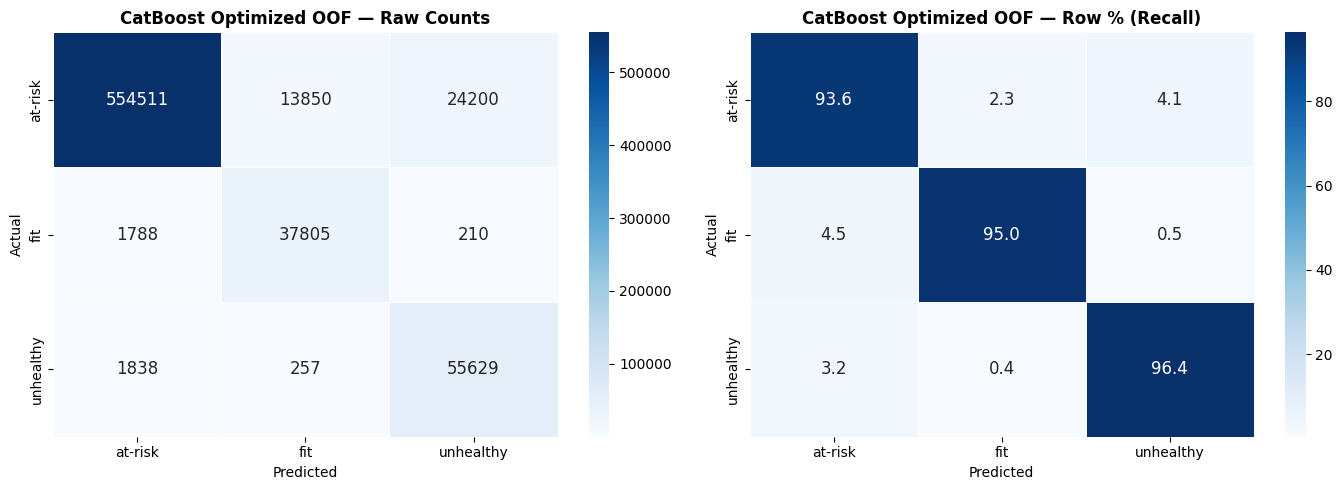

In [ ]:
results = evaluate_oof(
    y_true=y,
    probs=oof_probs,
    class_names=le.classes_,
    class_weights=best_weights,
    title="CatBoost Optimized OOF"
)

# Error Analysis

In [ ]:
optimized_probs = oof_probs*best_weights
y_pred = optimized_probs.argmax(axis = 1)

error_df, errors = analyze_errors(
    df=train,
    y_true=y,
    y_pred=y_pred,
    label_encoder=le,
    analysis_cols=[
        "stress_level",
        "physical_activity_level",
        "sleep_quality"
    ]
)

Total errors: 42,143 (6.11%)

Errors by TRUE class:
y_true
at-risk      38050
unhealthy     2095
fit           1998

Top confusion pairs (true → predicted):
y_true     y_pred   
at-risk    unhealthy    24200
           fit          13850
unhealthy  at-risk       1838
fit        at-risk       1788
unhealthy  fit            257
fit        unhealthy      210

Errors by stress_level:
stress_level
missing    21033
high       14141
low         5255
medium      1714

Errors by physical_activity_level:
physical_activity_level
active       19700
moderate      9607
sedentary     8958
missing       3878

Errors by sleep_quality:
sleep_quality
poor       14533
average    13498
good       10535
missing     3577
